<a href="https://colab.research.google.com/github/drtommyhudson77-ai/gdp-dashboard/blob/main/Normal_Gaussian_IQ_Distribution3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

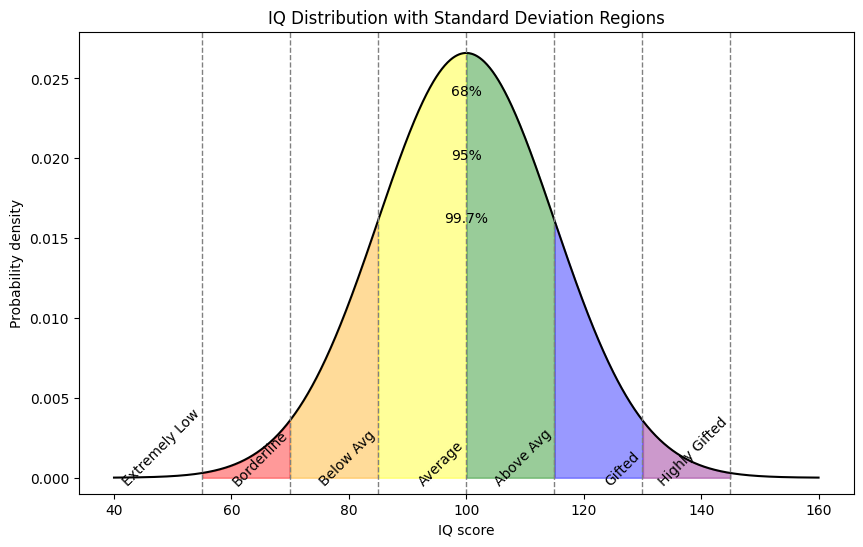

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
mean = 100
std = 15

# Generate x values
x = np.linspace(40, 160, 1000)

# Normal distribution
y = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)

# Plot curve
plt.figure(figsize=(10, 6))
plt.plot(x, y, color='black')

# Define SD regions and colors
regions = [
    (-3, -2, 'red'),
    (-2, -1, 'orange'),
    (-1, 0, 'yellow'),
    (0, 1, 'green'),
    (1, 2, 'blue'),
    (2, 3, 'purple')
]

# Shade regions
for start, end, color in regions:
    a = mean + start * std
    b = mean + end * std
    mask = (x >= a) & (x <= b)
    plt.fill_between(x[mask], y[mask], color=color, alpha=0.4)

# Vertical SD lines
for i in range(-3, 4):
    plt.axvline(mean + i * std, linestyle='--', color='gray', linewidth=1)

# ---- Percent Labels (68–95–99.7 rule) ----
plt.text(100, max(y)*0.90, "68%", ha='center')
plt.text(100, max(y)*0.75, "95%", ha='center')
plt.text(100, max(y)*0.60, "99.7%", ha='center')

# ---- IQ Category Labels ----
categories = [
    (55, "Extremely Low"),
    (70, "Borderline"),
    (85, "Below Avg"),
    (100, "Average"),
    (115, "Above Avg"),
    (130, "Gifted"),
    (145, "Highly Gifted"),
]

for xpos, label in categories:
    plt.text(xpos, -0.0005, label, rotation=45, ha='right')

# Labels
plt.title('IQ Distribution with Standard Deviation Regions')
plt.xlabel('IQ score')
plt.ylabel('Probability density')

# Adjust limits so labels are visible
plt.ylim(bottom=-0.001)

plt.show()

In [8]:
import numpy as np
import plotly.graph_objects as go

# Parameters
mean = 100
std = 15

# Data
x = np.linspace(40, 160, 1000)
y = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)

# SD tick positions (IQ scores)
ticks = [mean + i * std for i in range(-3, 4)]

# Category labels (positioned between ranges)
category_positions = [55, 70, 85, 100, 115, 130, 145]
category_labels = [
    "Extremely Low",
    "Borderline",
    "Below Avg",
    "Average",
    "Above Avg",
    "Gifted",
    "Highly Gifted"
]

# Create figure
fig = go.Figure()

# Main curve
fig.add_trace(go.Scatter(
    x=x,
    y=y,
    mode='lines',
    line=dict(color='black', width=3),
    name='IQ Distribution',
    hovertemplate='IQ: %{x:.0f}<br>Density: %{y:.4f}<extra></extra>'
))

# Regions (legend retained)
regions = [
    (-3, -2, 'red', '2.1%'),
    (-2, -1, 'orange', '13.6%'),
    (-1, 0, 'yellow', '34.1%'),
    (0, 1, 'green', '34.1%'),
    (1, 2, 'blue', '13.6%'),
    (2, 3, 'purple', '2.1%')
]

for start, end, color, pct in regions:
    a = mean + start * std
    b = mean + end * std
    mask = (x >= a) & (x <= b)

    fig.add_trace(go.Scatter(
        x=x[mask],
        y=y[mask],
        fill='tozeroy',
        mode='lines',
        line=dict(color=color),
        fillcolor=color,
        opacity=0.4,
        name=f"{start}σ to {end}σ ({pct})",
        hovertemplate=f"IQ range: {a:.0f}–{b:.0f}<br>Population: {pct}<extra></extra>"
    ))

# Vertical SD lines
for val in ticks:
    fig.add_vline(x=val, line_dash="dash", line_color="gray")

# ✅ Numeric IQ ticks (main axis)
fig.update_xaxes(
    tickmode='array',
    tickvals=ticks,
    ticktext=[f"{int(t)}" for t in ticks]
)

# ✅ Add category labels as a second "row" using annotations
for xpos, label in zip(category_positions, category_labels):
    fig.add_annotation(
        x=xpos,
        y=0,
        text=label,
        showarrow=False,
        yshift=-40,
        font=dict(size=11)
    )

# Layout
fig.update_layout(
    title="IQ Distribution with Standard Deviations",
    xaxis_title="IQ Score",
    yaxis_title="Probability Density",
    hovermode="x unified",
    width=1100,
    height=520,
    yaxis=dict(range=[0, max(y)*1.1]),
    legend_title="Standard Deviation Bands",
    margin=dict(b=100)  # ✅ extra space for category labels
)

fig.show()